# MNIST Dataset Loading Example

This notebook demonstrates how to load and visualize the MNIST dataset from the IDX format files.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from load_mnist import load_mnist

# Path to the MNIST dataset
dataset_path = '/Users/edvintb/experiments/datasets/mnist'

In [2]:
# Load training data
train_images, train_labels = load_mnist(dataset_path, 'train')
print(f"Training data: {train_images.shape} images, {train_labels.shape} labels")

# Load test data
test_images, test_labels = load_mnist(dataset_path, 't10k')
print(f"Test data: {test_images.shape} images, {test_labels.shape} labels")

Training data: (60000, 28, 28) images, (60000,) labels
Test data: (10000, 28, 28) images, (10000,) labels


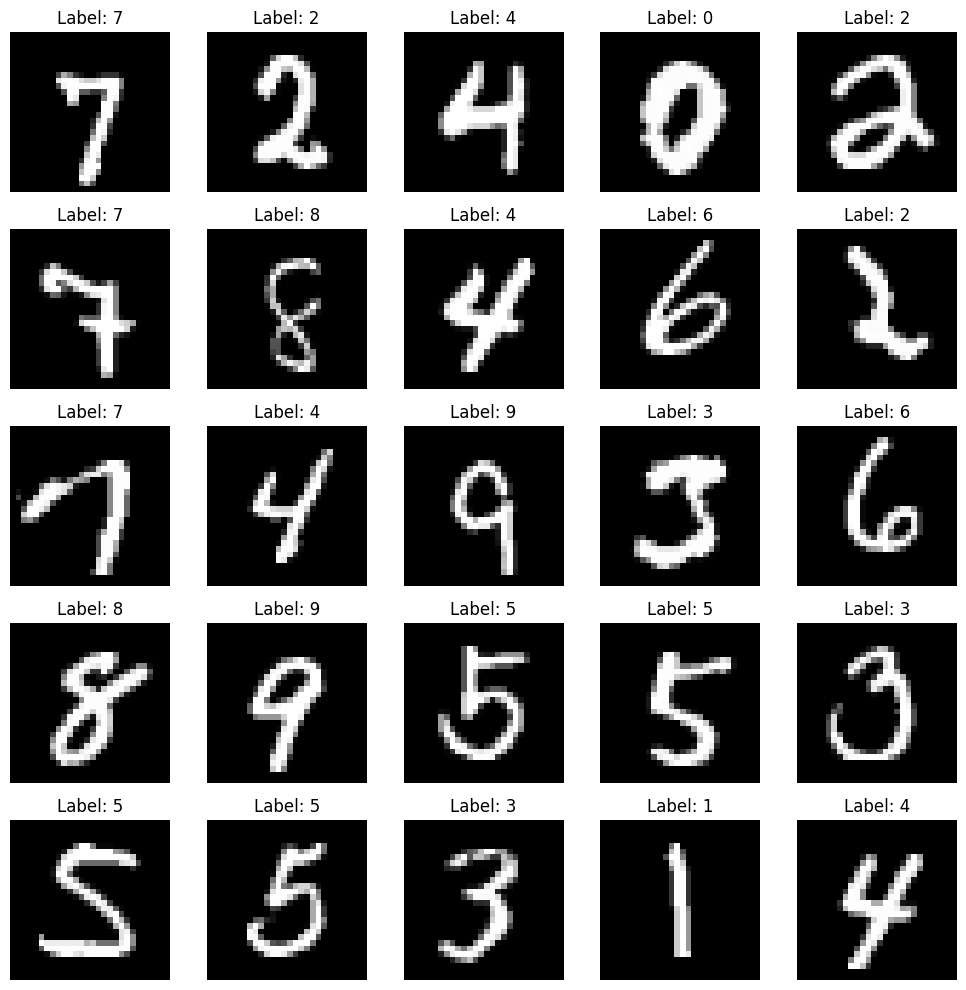

In [7]:
# Display a random grid of images
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()

# Select 25 random indices
random_indices = np.random.randint(0, len(train_images), 25)

for i, idx in enumerate(random_indices):
    axes[i].imshow(train_images[idx], cmap='gray')
    axes[i].set_title(f"Label: {train_labels[idx]}")
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()

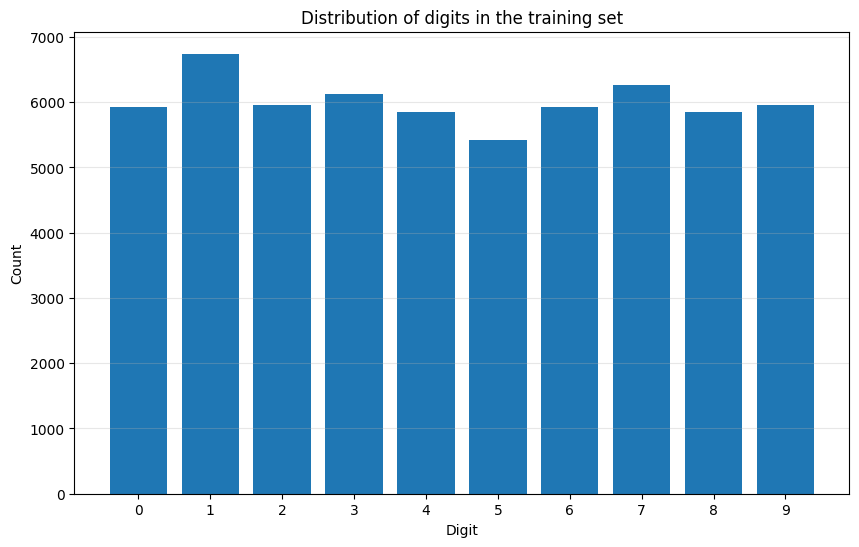

In [8]:
# Count the number of examples for each digit
unique, counts = np.unique(train_labels, return_counts=True)
class_distribution = dict(zip(unique, counts))

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of digits in the training set')
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)
plt.show()

## Preparing data for machine learning

Here's how you can prepare the MNIST data for machine learning tasks:

In [6]:
# Normalize the pixel values to [0, 1]
X_train = train_images.astype('float32') / 255.0
X_test = test_images.astype('float32') / 255.0

# Reshape for machine learning (flattening the images)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


Random vector index: 31443
Random vector label: 9
Random vector shape: (784,)
Random vector:
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        

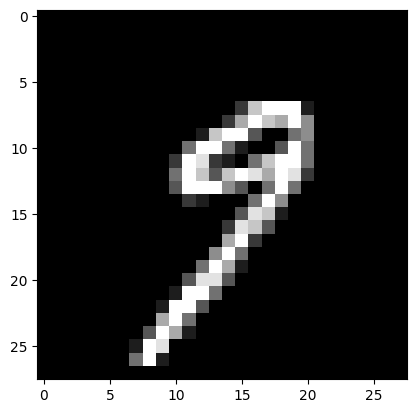

In [15]:
# pick a random vector and prin tit
rand_index = np.random.randint(0, len(X_train_flat))
rand_vector = X_train_flat[rand_index]
print(f"Random vector index: {rand_index}")
print(f"Random vector label: {train_labels[rand_index]}")
print(f"Random vector shape: {rand_vector.shape}")
print(f"Random vector:\n{rand_vector}")
reshaped_random = rand_vector.reshape(28, 28)
plt.imshow(reshaped_random, cmap='gray')
plt.show()

In [ ]:
# how can we tell which image belongs to which category?
# even though it seems obviuos when looking at the image which category it belongs to, it makes sense to think of each image as having a probability of belonging to each category. For example, in image (31443), are we 100% sure that it is a 9? I could imagine it was also intended to be a 4 or a 7. If I was asked about this image, I might say it's 95% a 9, 4% a 4, and 1% a 7. There isn't enough information in every image to be 100% sure of which category it belongs to. Therefore, instead of creating a model that predicts a single category for each image, we choose to create a model that predicts a probability for each category. This is a common thing to do in machine learning, precisely because one can seldom be 100% sure of the right answer from the label. 
# well, we have 10 different categories an image can belong to
# so 
# so let's project these large vectors (784 dim) vectors full of zeros into a 10-dimensional space
# there are tons of fancy ways to do this, but let's start with the simplest one:
